# Bitcoin OHLCV – Exploratory Data Analysis

# **Checkpoint 1 Submission: Bitcoin OHLCV Dataset**

---

## **(A) Identification of Candidate Datasets**

### **1) Bitcoin OHLCV Price/Volume Dataset**
• **Dataset Name & Source:** Kaggle: Bitcoin Historical Data (SwapTr)  
• **Course Topic Alignment:**  
o Large-Scale ML - modeling/predicting price and volume  
o Stream Mining - analyze rolling windows of high-frequency price/volume data  
o Anomaly Detection - detect unusual price/volume spikes  

• **Beyond-Course Techniques:**  
o LSTM/GRU or Transformer-based time-series forecasting  
o Change-point detection for structural breaks in price  
o Technical indicator-based predictive modeling (like RSI, Bollinger Bands)  

• **Dataset Size & Structure:** 1-minute OHLCV data, millions of rows covering several years  
• **Data Types:** Timestamp (datetime64[ns]); Open, High, Low, Close (float64); Volume (float64) (sometimes int64, but typically loaded as float64).  
• **Target Variable(s):** None for unsupervised tasks; can predict next-minute/hour price for supervised ML  
• **Licensing/Usage Constraints:** Public dataset; academic use allowed  

---

### **2) Smart Building / IoT Energy Dataset**
• **Dataset Name & Source:** UCI Individual Household Electric Power Consumption  
• **Course Topic Alignment:** Anomaly Detection, Stream Mining  

• **Beyond-Course Techniques:**  
o Variational Autoencoder (VAE) for unsupervised anomaly detection  
o Reinforcement Learning for energy optimization  
o LSTM-based forecasting of future consumption  

• **Dataset Size & Structure:** ~2M readings, 1-minute frequency over 4 years  
• **Data Types:** DateTime (datetime64[ns]); Global_active_power, Global_reactive_power, Voltage, Sub_metering_1–3 (float64)

• **Target Variable(s):** Optional anomaly labels  
• **Licensing/Usage Constraints:** Public; academic use allowed  

---

### **3) Human Activity Recognition (HAR) Dataset**
• **Dataset Name & Source:** UCI Human Activity Recognition Using Smartphones  
• **Course Topic Alignment:** Clustering, Anomaly Detection  

• **Beyond-Course Techniques:**  
o Transformer-based time-series classification  
o Graph-based sensor fusion  
o CNN-based feature learning for sequences  

• **Dataset Size & Structure:** 10,299 instances, 561 features, 30 participants  
• **Data Types:** Accelerometer & gyroscope features (float64); Activity label (int64) (or category if mapped)

• **Target Variable(s):** Activity class (Walking, Sitting, Laying, etc.)  
• **Licensing/Usage Constraints:** Public; academic use allowed  

---

## **(B) Comparative Analysis of Datasets**

| **Dataset** | **Supported Course Tasks** | **Data Quality Issues** | **Algorithmic Feasibility** | **Bias Considerations** | **Ethical Considerations** |
|-------------|----------------------------|--------------------------|-----------------------------|--------------------------|----------------------------|
| Bitcoin OHLCV | Stream Mining, LSTM/GRU | Missing timestamps (maybe), extreme outliers | High-frequency but manageable; LSTM/Transformer feasible | No participant bias; market microstructure bias possible | No personal data; financial ethics apply |
| IoT Energy | Anomaly Detection, VAE/LSTM/RL | Missing readings, sensor noise | Medium-size (feasible locally) | Limited household diversity (sample bias) | Household privacy; sensitive energy patterns |
| HAR Sensor | Clustering, CNN/ Transformer/ Graph | Sensor noise, missing readings | Small dataset (feasible locally) | Limited participants (activity bias) | Minimal; careful with health-related interpretations |

---

## **(C) Dataset Selection**

**Dataset:** Bitcoin OHLCV Price/Volume Dataset  

### **Reasons**
• Directly supports stream mining, anomaly detection, and large-scale ML (course topics)  
• Supports LSTM/Transformer forecasting and change-point detection (beyond-course)  
• Real-world, high-frequency, and large-scale enough for a data mining project  
• Clean numeric structure so manageable preprocessing and visualization  

### **Trade-offs**
• No graph structure, so cannot explore graph mining or network embeddings  
• Limited labeling, so can only do unsupervised or self-supervised tasks  

---

## **(D) Exploratory Data Analysis (EDA)**

**Python Notebook:**  
https://colab.research.google.com/drive/1mCJXpr5YFjWDJpYa3iUmoewNfwgo8HoI?usp=sharing  

### **Exploratory Data Analysis (EDA) Results**

### **1. Dataset Overview**
• Number of entries: 7,422,880 (1-minute intervals)  
• Columns: Timestamp, Open, High, Low, Close, Volume  
• Memory usage: 340 MB (can fit in memory comfortably)  

### **2. Numeric Summary**

| **Column** | **Min** | **25%** | **Median** | **75%** | **Max** | **Mean** | **Std** |
|------------|--------|--------|-----------|--------|--------|--------|--------|
| Open | 3.8 | 447.98 | 7475.0 | 34061.44 | 126202 | 22182 | 30721 |
| High | 3.8 | 448.01 | 7479.93 | 34079.24 | 126272 | 22190 | 30730 |
| Low | 3.8 | 447.83 | 7470.01 | 34040.91 | 126158 | 22174 | 30713 |
| Close | 3.8 | 447.99 | 7475.0 | 34061.78 | 126202 | 22182 | 30722 |
| Volume | 0.0 | 0.0203 | 0.4506 | 2.8759 | 5853.85 | 5.087 | 21.922 |

### **Observations from summary statistics**
• Prices range from \$3.8 to $126,202, showing massive growth and extreme scale differences over time.  
• Volumes are highly skewed: most 1-minute windows are very small (< 1 BTC), but occasional spikes reach thousands.  
• No missing values - dataset is clean.  

### **3. Time-Series Insights**
• Price trends: Clear long-term upward trend with spikes and dips (bull/bear cycles).  
• Volatility: Extreme spikes in log returns and volume correspond to sudden market events.  
• Volume spikes: Typically coincide with sharp price changes — useful for anomaly detection.  

### **4. Derived Features**
• Log Returns: `log_return = np.log(Close / Open)` - Distribution shows most 1-minute returns are tiny, occasional extreme returns indicate anomalies.  
• Rolling Volatility: Computed over 60-minute windows - Reveals clusters of high market activity (e.g., major price corrections or surges).  

---

## **(E) Initial Insights and Direction**

### **Observations**
1. Most price changes are small in a 1-minute window - extreme returns are rare but impactful.  
2. Volume spikes coincide with price swings - strong candidate for anomaly detection.  
3. Long-term trends with short-term noise - supports both forecasting and stream-based analysis.  

### **Hypotheses**
• High-frequency noise can mask meaningful patterns in short windows → rolling features or smoothing may improve forecasting accuracy.  
• Extreme price or volume events may indicate exploitable patterns (anomalies) for downstream analysis.  

### **Potential Research Questions (RQs)**
1. How do different rolling-window lengths affect the accuracy of LSTM/Transformer price forecasts?  
2. Can anomaly detection on log returns or volume identify periods of market instability?  
3. Do technical indicators (RSI, MACD) improve prediction over raw OHLCV features?  
4. How do extreme price movements correlate with volume spikes over varying time scales?  

---

## **(F) GitHub Portfolio Building**

• **Repository:** https://github.com/ShivaniSuresh1/bitcoin-ohlcv-mining  
• **Includes:**  
o EDA notebook with plots, log returns, volatility analysis  
o README describing dataset, EDA and project goals  

---

## **(G) Collaboration Declaration**
```
On my honor, I declare the following resources:

1. Collaborators:  
- None  

2. Web Sources:  
- https://pandas.pydata.org/docs/  
- https://numpy.org/doc/  
- https://matplotlib.org/stable/  
- https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data  

3. AI Tools:  
- ChatGPT – Used for structural refinement, documentation formatting and domain specific information.  

4. Citations (Papers Referenced Conceptually):  
- Mandelbrot, B. (1963). The Variation of Certain Speculative Prices. Journal of Business.: Justifies the observation that log returns exhibit heavy tails and deviate from Gaussian assumptions due to frequent extreme price movements.  
- Engle, R. (1982). Autoregressive Conditional Heteroskedasticity with Estimates of the Variance of UK Inflation. Econometrica.: Supports the identification of volatility clustering and time-varying variance in financial return series.  
- Bollerslev, T. (1986). Generalized Autoregressive Conditional Heteroskedasticity. Journal of Econometrics.: Motivates the use of rolling volatility and GARCH-type models to capture persistent conditional heteroskedasticity in returns.
```

In [ ]:
import kagglehub
import os
import zipfile

# Download dataset
path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")

print("Downloaded file path:", path)

Using Colab cache for faster access to the 'bitcoin-historical-data' dataset.
Downloaded file path: /kaggle/input/bitcoin-historical-data


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422880 entries, 0 to 7422879
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 339.8 MB
None
          Timestamp          Open          High           Low         Close  \
count  7.422880e+06  7.422880e+06  7.422880e+06  7.422880e+06  7.422880e+06   
mean   1.548103e+09  2.218213e+04  2.219002e+04  2.217405e+04  2.218214e+04   
std    1.285754e+08  3.072183e+04  3.073016e+04  3.071340e+04  3.072184e+04   
min    1.325412e+09  3.800000e+00  3.800000e+00  3.800000e+00  3.800000e+00   
25%    1.436755e+09  4.479800e+02  4.480100e+02  4.478300e+02  4.479900e+02   
50%    1.548098e+09  7.475000e+03  7.479930e+03  7.470010e+03  7.475000e+03   
75%    1.659442e+09  3.406144e+04  3.407924e+04  3.404091e+04  3.406178e+04   
max    1.770854e+

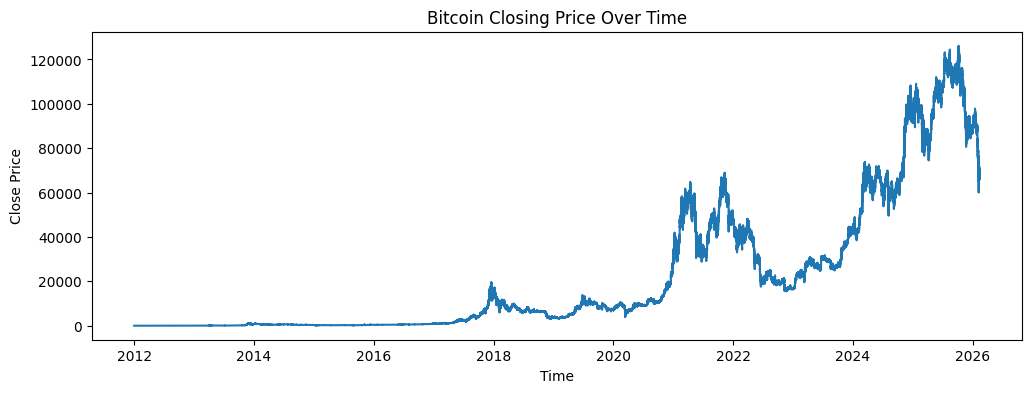

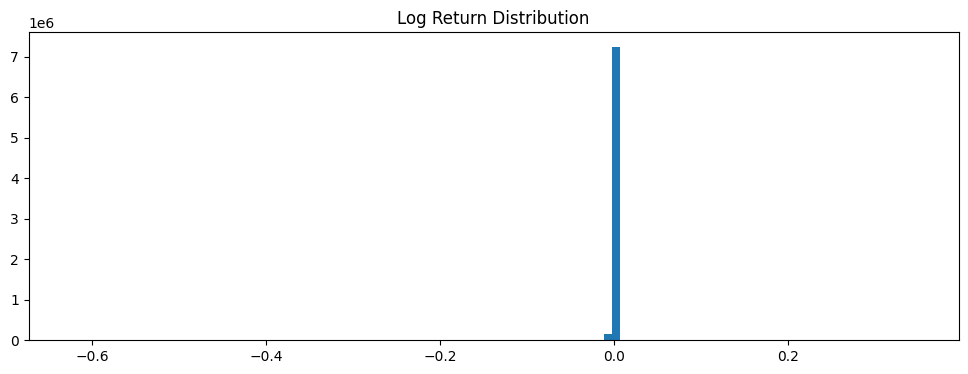

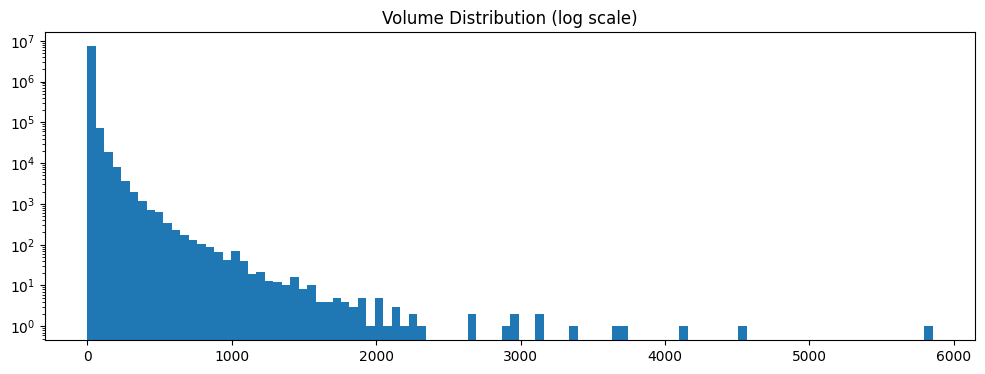

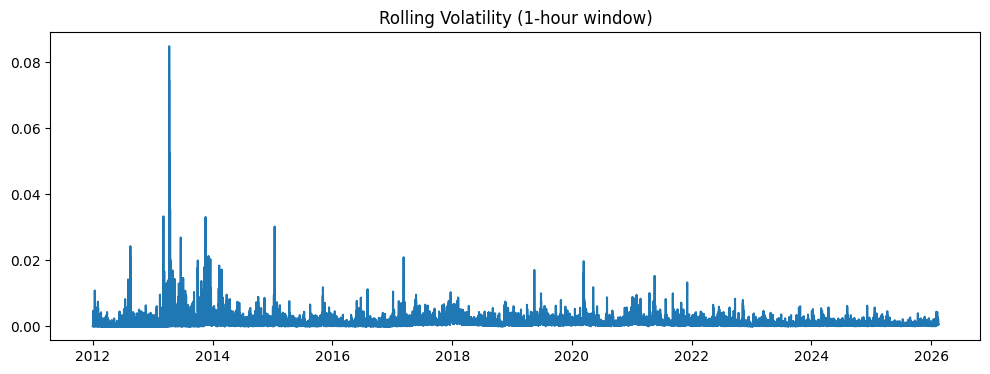

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv('/kaggle/input/bitcoin-historical-data/btcusd_1-min_data.csv')

# Basic info
print(df.info())
print(df.describe())

# Check for missing values
print(df.isnull().sum())

# Convert timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')

# Plot OHLC closing price over time
plt.figure(figsize=(12,4))
plt.plot(df['Timestamp'], df['Close'])
plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.show()

# Compute log returns
df['log_return'] = np.log(df['Close'] / df['Open'])
plt.figure(figsize=(12,4))
plt.hist(df['log_return'], bins=100)
plt.title("Log Return Distribution")
plt.show()

# Volume distribution
plt.figure(figsize=(12,4))
plt.hist(df['Volume'], bins=100, log=True)
plt.title("Volume Distribution (log scale)")
plt.show()

# Rolling volatility (1-hour window)
df['volatility'] = df['log_return'].rolling(60).std()
plt.figure(figsize=(12,4))
plt.plot(df['Timestamp'], df['volatility'])
plt.title("Rolling Volatility (1-hour window)")
plt.show()


# Bitcoin OHLCV – Exploratory Data Analysis

**Dataset:** 1-minute BTC/USD OHLCV data  
**Objective:** Understanding the data properties, distribution and temporal dynamics prior to modeling.

### 1. Environment Setup

####Import Required Libraries

- **pandas** - for tabular data manipulation and time-series handling.  
- **numpy** - for numerical computation (log returns, transformations).  
- **matplotlib** - for visualization.  

#### Algorithmic Decision & Justification

We use pandas + numpy + matplotlib because:
- The dataset (~340MB) fits in memory.
- Lightweight tools reduce computational overhead.
- Exploratory analysis does not require advanced visualization.

### 2. Data Loading

####a.  Load Dataset from Kaggle Input Directory

#### Algorithmic Decision & Justification

- The dataset size (~340MB) is manageable within Kaggle/Colab RAM limits.
- Direct loading avoids unnecessary complexity.


### 3. Initial Data Inspection

#### Structural Validation

Inspected attributes:

- Dataset dimensions  
- Column data types  
- Summary statistics  
- Missing values  

#### Algorithmic Decision & Justification

The check for missing values BEFORE any transformations because rolling statistics require continuous numeric data. Log transformations cannot operate on null values and early validation prevents silent propagation of NaNs.

If null values were present, we would:

- Use **forward-fill (ffill)** for appropriate for time-series continuity.
- Drop minimal corrupted rows if sparsely missing.

### 4. Timestamp Conversion

#### Convert Unix Timestamp to Datetime

- Enables proper time-series plotting.
- Required for resampling and temporal feature engineering.
- Prevents misinterpretation of x-axis ordering.

#### Algorithmic Decision & Justification

- Usage of `unit="s"` because timestamps are stored in Unix seconds.
- Datetime conversion ensures correct chronological ordering.
- Enables future grouping (hourly/daily aggregations).

### 5. Price Trend Analysis

#### Visualize Closing Price Over Time
- Represents the final traded price within each interval.
- Standard benchmark in financial modeling.
- Used to detect trends, regime shifts, and non-stationarity.

#### Algorithmic Decision & Justification

We select **Close** instead of Open/High/Low because:

- Close reflects market consensus at the end of each interval.
- Most financial models are built using closing prices.
- Reduces redundancy among highly correlated OHLC variables.

A large figure size is chosen to:

- Improve readability across long time horizons.
- Avoid compression of multi-year trends.

### 6. Log Return Computation

$$
r_t = \log(P_t) - \log(P_{t-1})
$$

Log Return is used because:
- Raw prices are non-stationary.
- Log returns stabilize variance.
- Convert multiplicative price changes into additive form.
- Standard in financial time-series modeling.

We prefer it over simple returns because:
- Log returns are time-additive.
- Better suited for volatility modeling.
- More numerically stable for ML algorithms.
- Theoretically grounded in continuous-time finance.

### 7. Distribution of Log Returns

#### Visualize Histogram
- Detect heavy tails.
- Identify extreme outliers.
- Assess Gaussian assumptions.

#### Algorithmic Decision & Justification

- Use **100 bins** since it provides enough granularity to reveal tail behavior and is not excessive to introduce histogram noise.
- Histogram is appropriate for direct distribution inspection.

#### Expected Insights

- Most returns concentrated near zero.
- Heavy-tailed distribution.
- Extreme spikes present.

#### Modeling Implications

- Anomaly detection may be appropriate.
- Volatility clustering expected.
- Gaussian assumptions likely invalid.

#### 8. Volume Distribution Analysis

#### Examine Trading Volume Distribution
- Volume is typically highly skewed.
- Extreme spikes distort linear-scale interpretation.

#### Algorithmic Decision & Justification

Usage of logarithmic y-axis:
  - Volume is heavy-tailed.
  - Prevents rare spikes from dominating visualization.
  - Improves interpretability of majority behavior.

#### Insight

- Most 1-minute windows have low volume.
- Rare extreme bursts exist.
- Indicates episodic liquidity surges.

### 9. Rolling Volatility Estimation

#### Compute 60-Minute Rolling Standard Deviation
- 60 minutes = 1 hour (natural financial aggregation unit).
- Captures short-term intraday volatility.
- Balances noise reduction and responsiveness.

#### Algorithmic Decision & Justification

We use rolling standard deviation of log returns because:
- It is a standard proxy for realized volatility.
- Captures volatility clustering behavior.
- Widely used in financial literature.

#### Alternative Windows Considered

| Window | Reason Rejected |
|--------|-----------------|
| 5-minute | Too noisy |
| 24-hour | Overly smooth, hides intraday clustering |

60-minute window selected as optimal balance.

### Overall Insights from EDA

1. BTC price series is strongly non-stationary.
2. Log returns exhibit heavy tails.
3. Volume distribution is highly skewed.
4. Volatility clustering is clearly present.
5. Gaussian modeling assumptions are likely inappropriate.

These findings motivate:

- Volatility modeling
- Anomaly detection frameworks
- Non-Gaussian probabilistic models
- Regime-switching approaches

```
On my honor, I declare the following resources:

1. Collaborators:
- None

2. Web Sources:
- https://pandas.pydata.org/docs/  
- https://numpy.org/doc/  
- https://matplotlib.org/stable/  
- https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data  

3. AI Tools:
- ChatGPT – Used for structural refinement, documentation formatting and domain specific information.

4. Citations (Papers Referenced Conceptually):
- Mandelbrot, B. (1963). The Variation of Certain Speculative Prices. Journal of Business.: Justifies the observation that log returns exhibit heavy tails and deviate from Gaussian assumptions due to frequent extreme price movements.
- Engle, R. (1982). Autoregressive Conditional Heteroskedasticity with Estimates of the Variance of UK Inflation. Econometrica.: Supports the identification of volatility clustering and time-varying variance in financial return series.
- Bollerslev, T. (1986). Generalized Autoregressive Conditional Heteroskedasticity. Journal of Econometrics.: Motivates the use of rolling volatility and GARCH-type models to capture persistent conditional heteroskedasticity in returns.

```